Il est important que les sociétés de cartes de crédit soient capables de reconnaître les transactions frauduleuses afin que les clients ne soient pas facturés pour des articles qu'ils n'ont pas achetés.

### Projet 4 : Détection de fraude

## Contenu

L'ensemble de données contient les transactions par carte bancaire effectuées en septembre 2013 par des titulaires européens.
Il présente les transactions réalisées sur deux jours et recense 492 fraudes sur 284 807 transactions. L'ensemble de données est fortement déséquilibré : les transactions frauduleuses ne représentent que 0,172 % du total.

Ce jeu de données contient uniquement des variables d'entrée numériques, issues d'une transformation ACP. Malheureusement, pour des raisons de confidentialité, nous ne pouvons fournir ni les variables d'origine ni d'informations complémentaires sur les données. Les variables V1, V2, …, V28 correspondent aux composantes principales obtenues par ACP. Seules les variables « Temps » et « Montant » n'ont pas été transformées par ACP. La variable « Temps » représente le temps écoulé en secondes entre chaque transaction et la première transaction du jeu de données. La variable « Montant » correspond au montant de chaque transaction ; elle peut être utilisée pour un apprentissage sensible aux coûts et dépendant des exemples. La variable « Classe » est la variable réponse : elle prend la valeur 1 en cas de fraude et 0 sinon.

Compte tenu du déséquilibre des classes, nous recommandons de mesurer la précision à l'aide de l'aire sous la courbe précision-rappel (AUPRC). La précision de la matrice de confusion n'est pas pertinente pour une classification déséquilibrée.

 **1.  1. Importation des bibliothèques**

Pour réaliser l’analyse exploratoire des données (EDA), nous importons les bibliothèques Python nécessaires à la manipulation, à l’analyse et à la visualisation des données.

NumPy (`numpy`)est utilisé pour les opérations numériques et la manipulation de données sous forme de tableaux.
Pandas(`pandas`)permet de charger, manipuler et analyser le jeu de données sous forme de DataFrame.
Matplotlib **(`matplotlib.pyplot`)** permet de réaliser des visualisations graphiques afin de mieux comprendre les caractéristiques et la distribution des données.

Ces bibliothèques constituent la base des différentes étapes d’exploration qui seront réalisées par la suite.



In [2]:
# importation des bibliotheque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

 **2. Chargement des données**

Après avoir importé les bibliothèques nécessaires, nous chargeons le jeu de données dans un DataFrame Pandas.

Le jeu de données utilisé dans ce projet contient des transactions bancaires et la variable cible `Class`, qui permet d'identifier les transactions normales (`0`) et frauduleuses (`1`).

Le chargement des données constitue une étape préalable à l'analyse exploratoire. Il nous permettra ensuite d'étudier la structure du jeu de données, ses dimensions, ses variables, ses types de données, ses valeurs manquantes, ses doublons et ses principales caractéristiques statistiques.

In [8]:
df = pd.read_csv("../data/creditcard.csv")

 **3. Aperçu des premières lignes**

Après avoir chargé le jeu de données, nous affichons les premières observations afin d’obtenir un premier aperçu de son contenu.

Cette étape permet de vérifier que les données ont été correctement chargées et d’observer les premières valeurs des différentes variables présentes dans le jeu de données. Elle constitue une première vérification avant d’analyser plus en détail sa structure et ses caractéristiques.


In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Interprétation :**

L’aperçu des premières lignes confirme que le jeu de données a été correctement chargé. Le DataFrame contient 31 variables, parmi lesquelles `Time`, les variables anonymisées `V1` à `V28`, `Amount` et la variable cible `Class`.

Les premières observations affichées ont une valeur `Class` égale à `0`, ce qui correspond à des transactions non frauduleuses. Cette observation concerne uniquement les premières lignes et ne permet pas encore de conclure sur la répartition globale des transactions entre les deux classes.

Les variables `V1` à `V28` sont présentées sous forme de valeurs numériques, tandis que `Time` et `Amount` correspondent respectivement au temps de la transaction et à son montant.


 **4. Aperçu des dernières lignes**

Après avoir observé les premières observations du jeu de données, nous affichons également les dernières lignes afin de vérifier le contenu situé à la fin du dataset.

Cette vérification permet de compléter l’observation réalisée avec `df.head()` et de s’assurer que les dernières observations sont correctement présentes avant de poursuivre l’analyse de la structure du jeu de données.


In [10]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


**Interprétation :**

L’affichage des dernières lignes confirme que le jeu de données contient bien des observations jusqu’à l’indice `284806`. Les dernières observations présentent les mêmes variables que celles observées au début du jeu de données, soit 31 colonnes.

Dans les cinq dernières observations affichées, la variable `Class` prend la valeur `0`. Cela indique que ces observations correspondent à des transactions non frauduleuses. Cependant, cette observation porte uniquement sur les dernières lignes affichées et ne permet pas de déterminer la répartition globale des classes dans le jeu de données.


 **5. Dimensions du jeu de données**

Après avoir observé les premières et les dernières lignes du jeu de données, nous allons déterminer ses dimensions afin de connaître le nombre total d’observations et de variables pour cela on utilise **df.shape**

Cette information permet de mesurer la taille du jeu de données et constitue une première étape pour comprendre l’ampleur des données disponibles pour l’analyse.


In [11]:
df.shape

(284807, 31)

Interprétation :

Le résultat indique que le jeu de données contient **284 807 observations** et **31 variables**.

Les 284 807 observations correspondent aux transactions bancaires présentes dans le dataset. Les 31 variables correspondent aux caractéristiques disponibles pour décrire ces transactions, notamment `Time`, les variables anonymisées `V1` à `V28`, `Amount` et la variable cible `Class`.


 6. Analyse des colonnes

Pourquoi ?

Après avoir déterminé les dimensions du dataset, il est nécessaire d’identifier les différentes variables disponibles. Cette étape permet de comprendre la structure des données et de repérer les variables qui pourront être utilisées pour analyser les transactions.

Comment ?

Nous allons afficher les noms de toutes les colonnes du DataFrame à l’aide de l’attribut `columns`.

Objectif :

Identifier les variables présentes dans le dataset et repérer notamment la variable cible `Class`, qui indique si une transaction est frauduleuse ou non.


In [12]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Interprétation :

Le dataset contient **31 colonnes** : `Time`, les variables `V1` à `V28`, `Amount` et `Class`.

Les variables `V1` à `V28` correspondent à des variables numériques anonymisées issues d’une transformation en composantes principales (PCA). `Time` représente le temps écoulé depuis la première transaction et `Amount` correspond au montant de la transaction.

Enfin, `Class` est la variable cible : `0` correspond à une transaction normale et `1` à une transaction frauduleuse.


### 7. Types de données

**Pourquoi ?**

Après avoir identifié les différentes colonnes du dataset, il est nécessaire de vérifier le type de données associé à chacune d’elles. Cette vérification permet de s’assurer que les variables sont correctement interprétées par Pandas et qu’elles pourront être utilisées correctement lors des analyses statistiques et des visualisations.

**Comment ?**

Nous allons utiliser l’attribut `dtypes` du DataFrame afin d’afficher le type de données de chaque colonne.

**Objectif :**

Vérifier la structure des données et détecter d’éventuelles incohérences de type qui pourraient nécessiter un traitement avant les étapes suivantes de l’analyse.

In [13]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

**Interprétation :**

Les variables `Time`, `V1` à `V28` et `Amount` sont de type `float64`, ce qui est cohérent avec leur nature numérique.

La variable `Class` est de type `int64`, ce qui est également adapté puisqu’elle contient les valeurs `0` et `1` permettant d’identifier les transactions normales et frauduleuses.

Aucune incohérence de type n’est observée à cette étape.


### 8. Analyse des valeurs manquantes

**Pourquoi ?**

La présence de valeurs manquantes peut affecter les analyses statistiques et certaines étapes de modélisation. Il est donc nécessaire de vérifier la qualité des données avant de poursuivre l’analyse exploratoire.

**Comment ?**

Nous allons compter le nombre de valeurs manquantes dans chaque colonne du DataFrame à l’aide de la méthode `isnull().sum()`.

**Objectif :**

Identifier les colonnes contenant des valeurs manquantes et déterminer si un traitement sera nécessaire avant les étapes suivantes.


In [14]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

**Interprétation :**

Aucune valeur manquante n’est présente dans le dataset : toutes les colonnes ont **0 valeur manquante**.

Le dataset ne présente donc pas de problème de données manquantes à ce stade. Aucun traitement spécifique des valeurs manquantes ne sera nécessaire pour cette partie de l’analyse.


### 9. Analyse des doublons

**Pourquoi ?**

La présence de doublons peut fausser les statistiques et donner une représentation incorrecte des transactions. Il est donc nécessaire de vérifier si certaines observations sont enregistrées plusieurs fois.

**Comment ?**

Nous allons utiliser la méthode `duplicated()` de Pandas pour identifier les lignes entièrement identiques, puis `sum()` pour obtenir leur nombre total.

**Objectif :**

Déterminer si le dataset contient des observations dupliquées et vérifier si un traitement sera nécessaire avant de poursuivre l’analyse.


In [15]:
df.duplicated().sum()

np.int64(1081)

**Interprétation :**

Le dataset contient **1 081 observations dupliquées**.

Ces doublons peuvent influencer les statistiques descriptives et donner davantage de poids à certaines transactions. Ils devront donc être pris en compte dans les étapes de préparation des données avant la modélisation.


### 10. Statistiques descriptives

**Pourquoi ?**

Après avoir vérifié la structure et la qualité du dataset, il est nécessaire d’étudier les principales caractéristiques statistiques des variables numériques. Cette analyse permet de mieux comprendre les valeurs observées et leur dispersion.

**Comment ?**

Nous allons utiliser la méthode `describe()` de Pandas. Elle fournit notamment le nombre d’observations, la moyenne, l’écart-type, les valeurs minimale et maximale ainsi que les quartiles.

**Objectif :**

Obtenir une première synthèse statistique des variables numériques et repérer d’éventuelles valeurs atypiques qui pourront être étudiées plus en détail dans la suite de l’analyse.


In [16]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Interprétation :**

Les variables `V1` à `V28` ont des **moyennes proches de zéro**, ce qui est cohérent avec leur transformation par PCA. Leur **écart-type** varie selon les variables, ce qui indique des niveaux de dispersion différents autour de leur moyenne.

Pour `Amount`, la **moyenne est de 88,35**, avec un **écart-type de 250,12**. Les montants vont d’un **minimum de 0** à un **maximum de 25 691,16**, ce qui montre une forte dispersion et la présence de transactions avec des montants très élevés.

Enfin, pour `Class`, la **moyenne est de 0,001727**, ce qui confirme que les transactions frauduleuses sont très minoritaires. Cette caractéristique sera étudiée plus précisément dans l’analyse du déséquilibre des classes.


### 11. Analyse de la variable cible `Class`

**Pourquoi ?**

La variable `Class` est la variable cible du projet de détection de fraude. Elle permet de distinguer les transactions normales (`0`) des transactions frauduleuses (`1`).

Il est donc nécessaire d’étudier sa répartition avant de poursuivre l’analyse, notamment pour identifier un éventuel déséquilibre entre les deux classes.

**Comment ?**

Nous allons compter le nombre d’observations appartenant à chaque valeur de `Class` à l’aide de la méthode `value_counts()`.

**Objectif :**

Déterminer le nombre de transactions normales et frauduleuses afin de mieux comprendre la répartition de la variable cible.


In [17]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

**Interprétation :**

La variable `Class` montre que le dataset contient **284 315 transactions normales (`Class = 0`)** contre seulement **492 transactions frauduleuses (`Class = 1`)**.

Les transactions frauduleuses représentent donc une très faible proportion des observations par rapport aux transactions normales. Cette forte différence entre les deux classes confirme la présence d’un **déséquilibre important des classes**, qui devra être pris en compte dans la suite du projet.


### 12. Proportion des classes

**Pourquoi ?**

Après avoir déterminé le nombre de transactions appartenant à chaque classe, il est utile de calculer leur proportion dans l’ensemble du dataset. Les pourcentages permettent de mesurer plus précisément l’importance de chaque classe et de quantifier le déséquilibre observé.

**Comment ?**

Nous allons utiliser `value_counts(normalize=True)` afin d’obtenir la proportion de chaque valeur de `Class`, puis la multiplier par 100 pour obtenir les pourcentages.

**Objectif :**

Mesurer la proportion de transactions normales et frauduleuses afin de quantifier le déséquilibre entre les deux classes.on s'etait arreter a cette etape la 

In [18]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

**Interprétation :**

Les transactions normales représentent **99,827251 %** du dataset, tandis que les transactions frauduleuses représentent seulement **0,172749 %**.

Cette répartition montre un **fort déséquilibre des classes** : les transactions frauduleuses sont très minoritaires par rapport aux transactions normales. Ce déséquilibre devra être pris en compte lors des étapes de préparation des données et de modélisation.


### 13. Visualisation du déséquilibre des classes

**Pourquoi ?**

Les résultats précédents ont montré que les transactions frauduleuses représentent seulement **0,172749 %** du dataset. Une représentation graphique permet de visualiser directement l’écart entre les transactions normales et frauduleuses.

**Comment ?**

Nous allons utiliser un diagramme en barres représentant le nombre de transactions pour chaque valeur de `Class`.

**Objectif :**

Visualiser clairement le déséquilibre entre les transactions normales (`0`) et frauduleuses (`1`), afin de mettre en évidence la faible proportion de fraudes dans le dataset.


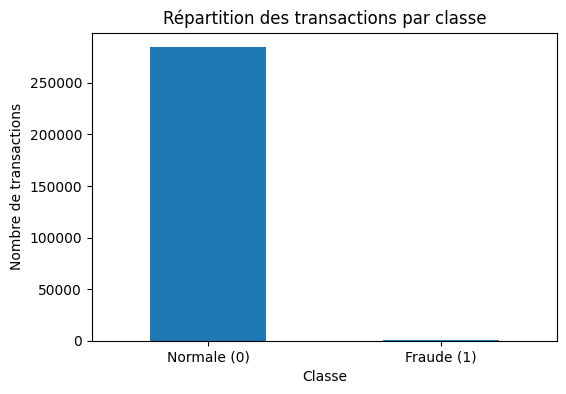

In [19]:
df["Class"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.xlabel("Classe")
plt.ylabel("Nombre de transactions")
plt.title("Répartition des transactions par classe")
plt.xticks([0, 1], ["Normale (0)", "Fraude (1)"], rotation=0)
plt.show()

### Explication du code

Le code ci-dessus permet de créer un **diagramme en barres** représentant le nombre de transactions normales et frauduleuses.

* `df["Class"]` : sélectionne la colonne `Class` du DataFrame. Cette colonne indique la classe de chaque transaction : `0` pour une transaction normale et `1` pour une transaction frauduleuse.

* `.value_counts()` : compte le nombre d'occurrences de chaque valeur dans la colonne `Class`. On obtient donc le nombre de transactions normales et le nombre de transactions frauduleuses.

* `.sort_index()` : trie les résultats selon la valeur de la classe, afin d'avoir les classes dans l'ordre `0` puis `1`.

* `.plot(...)` : permet de représenter graphiquement les résultats.

* `kind="bar"` : indique que nous voulons utiliser un **diagramme en barres verticales**.

* `figsize=(6, 4)` : définit la taille du graphique, avec une largeur de `6` pouces et une hauteur de `4` pouces.

* `plt.xlabel("Classe")` : ajoute le nom **« Classe »** sur l'axe horizontal.

* `plt.ylabel("Nombre de transactions")` : ajoute le nom **« Nombre de transactions »** sur l'axe vertical.

* `plt.title("Répartition des transactions par classe")` : ajoute le titre du graphique.

* `plt.xticks([0, 1], ["Normale (0)", "Fraude (1)"], rotation=0)` : remplace les valeurs `0` et `1` affichées sur l'axe horizontal par les labels **« Normale (0) »** et **« Fraude (1) »**. `rotation=0` permet de garder les labels horizontaux.

* `plt.show()` : affiche le graphique dans le notebook.

Ainsi, l'ensemble du code permet de **visualiser rapidement la différence entre le nombre de transactions normales et le nombre de transactions frauduleuses**.


**Interprétation :**

Le graphique met clairement en évidence un **fort déséquilibre des classes**. Classe 0 (Normale) : environ 284 000 transactions
Classe 1 (Fraude) : un nombre très faible, presque invisible sur le graphique (probablement quelques centaines)

Les transactions frauduleuses représentent 0,172749 % du dataset. Ce pourcentage est obtenu à partir du calcul précédent avec value_counts(normalize=True) * 100, soit :

On cherche le pourcentage de fraudes parmi toutes les transactions.

1. On part des deux nombres
Nombre de fraudes = 492
Nombre total de transactions = 284 807

Donc :

$$ \frac{492}{284\,807} $$

Cela donne environ :

$$ 0,00172749 $$
2. On transforme en pourcentage

Pour passer d'une proportion à un pourcentage, on multiplie par 100 :

$$ 0,00172749 \times 100 = 0,172749\% $$

Donc :

492 fraudes sur 284 807 transactions = 0,172749 % de fraudes.

Les transactions frauduleuses constituent donc une très faible proportion des observations. Ce déséquilibre constitue un élément important à prendre en compte pour la suite du projet, notamment lors de la modélisation et de l’évaluation des performances des modèles.


### 14. Analyse de la variable `Amount`

**Pourquoi ?**

La variable `Amount` représente le montant de chaque transaction. Son analyse permet de comprendre comment les montants sont répartis dans le dataset et d'identifier d'éventuelles valeurs extrêmes.

**Comment ?**

Nous allons d'abord utiliser `df["Amount"].describe()` pour obtenir les principales statistiques descriptives de cette variable. Nous utiliserons ensuite un histogramme et un boxplot afin de visualiser sa distribution et de repérer d'éventuelles valeurs atypiques.

**Objectif :**

Déterminer si la majorité des transactions ont de petits montants et identifier la présence éventuelle de valeurs extrêmes.


In [21]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

**Interprétation :**

La variable `Amount` présente une **moyenne de 88,35** et une **médiane de 22,00**. Le fait que la moyenne soit nettement supérieure à la médiane indique que la distribution des montants est probablement **asymétrique**, avec des transactions de montants élevés qui tirent la moyenne vers le haut.

La moitié des transactions ont un montant inférieur ou égal à **22,00**, tandis que 75 % des transactions ont un montant inférieur ou égal à **77,165**.

Les montants vont de **0,00** à **25 691,16**, avec un **écart-type de 250,12**, ce qui montre une forte dispersion et suggère la présence de **valeurs extrêmes**.

Une visualisation graphique sera donc utile pour confirmer cette distribution et identifier plus clairement les éventuels outliers.


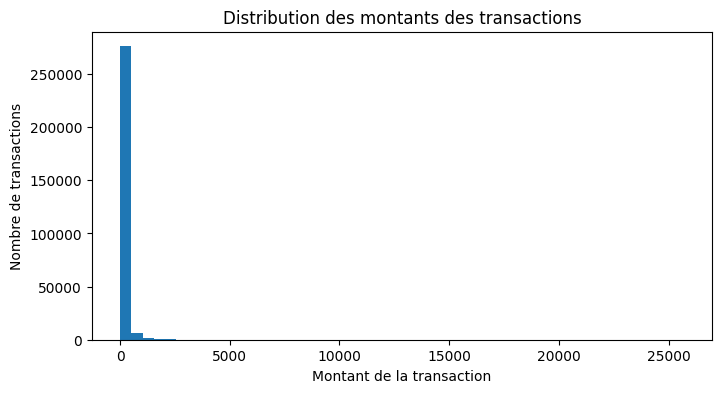

In [22]:
df["Amount"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)

plt.xlabel("Montant de la transaction")
plt.ylabel("Nombre de transactions")
plt.title("Distribution des montants des transactions")
plt.show()

### Explication du code de l'histogramme

```python
df["Amount"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)
```

* `df["Amount"]` : sélectionne la colonne `Amount` du DataFrame `df`.
* `.plot()` : permet de créer un graphique à partir des données sélectionnées.
* `kind="hist"` : indique que nous voulons créer un **histogramme** (`hist` signifie *histogram*).
* `bins=50` : divise les valeurs de `Amount` en **50 intervalles** afin de représenter leur distribution.
* `figsize=(8, 4)` : définit la taille du graphique, avec **8 pouces de largeur** et **4 pouces de hauteur**.

```python
plt.xlabel("Montant de la transaction")
```

Cette ligne définit le **nom de l'axe horizontal (axe X)**. Il représente ici le montant de la transaction.

```python
plt.ylabel("Nombre de transactions")
```

Cette ligne définit le **nom de l'axe vertical (axe Y)**. Il représente le nombre de transactions présentes dans chaque intervalle de montant.

```python
plt.title("Distribution des montants des transactions")
```

Cette ligne ajoute le **titre du graphique**, afin d'indiquer clairement ce que représente l'histogramme.

```python
plt.show()
```

Cette commande demande à Matplotlib **d'afficher le graphique** dans le notebook.



**Interprétation :**

L'histogramme montre que la grande majorité des transactions ont des **montants relativement faibles**, principalement concentrés dans les premières tranches de l'histogramme.

La distribution de `Amount` est **fortement asymétrique à droite** : la majorité des transactions ont de petits montants, tandis qu'un nombre beaucoup plus faible de transactions présente des montants élevés, avec un maximum de **25 691,16**.

Cette asymétrie est cohérente avec les statistiques descriptives : la **moyenne (88,35)** est nettement supérieure à la **médiane (22,00)**. Les montants élevés contribuent donc à augmenter la moyenne.

Enfin, la forte concentration des observations sur les petits montants rend les transactions de montant élevé difficiles à distinguer visuellement sur cet histogramme. Le **boxplot** permettra de compléter cette analyse et de mieux mettre en évidence les éventuelles valeurs extrêmes.


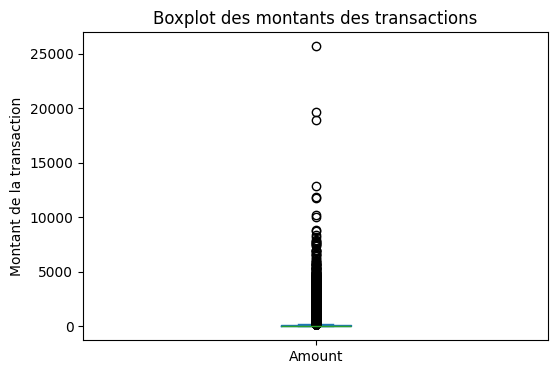

In [23]:
df["Amount"].plot(
    kind="box",
    figsize=(6, 4)
)

plt.ylabel("Montant de la transaction")
plt.title("Boxplot des montants des transactions")
plt.show()

Pourquoi ?

Le boxplot complète l’histogramme. Il permet notamment de visualiser :

la médiane ;
les quartiles ;
la dispersion des montants ;
les éventuelles valeurs extrêmes (outliers).

Ici, nous voulons surtout vérifier visuellement si les montants très élevés observés dans describe() apparaissent comme des valeurs atypiques.

### Explication du code du boxplot

```python
df["Amount"].plot(
    kind="box",
    figsize=(6, 4)
)
```

* `df["Amount"]` : sélectionne la colonne `Amount` du DataFrame `df`.
* `.plot()` : permet de créer un graphique à partir des données sélectionnées.
* `kind="box"` : indique que nous voulons créer un **boxplot**, aussi appelé diagramme en boîte.
* `figsize=(6, 4)` : définit la taille du graphique, avec **6 pouces de largeur** et **4 pouces de hauteur**.

```python
plt.ylabel("Montant de la transaction")
```

Cette ligne définit le **nom de l'axe vertical (axe Y)**. Il représente le montant des transactions.

```python
plt.title("Boxplot des montants des transactions")
```

Cette ligne ajoute le **titre du graphique**, afin d'indiquer clairement que le graphique représente la distribution des montants des transactions.

```python
plt.show()
```

Cette commande demande à Matplotlib **d'afficher le boxplot** dans le notebook.

**Rappel :**

Le boxplot permet notamment d'observer la **médiane**, les **quartiles**, les **moustaches** et les éventuelles **valeurs atypiques (outliers)**.


**Interprétation :**

Le boxplot confirme que la variable `Amount` présente une **forte asymétrie vers les montants élevés**. La boîte est concentrée près de 0, ce qui est cohérent avec le fait que **75 % des transactions ont un montant inférieur ou égal à 77,165**.

De nombreuses observations apparaissent au-dessus des moustaches du boxplot. Elles sont considérées comme des **valeurs atypiques (outliers)** selon la règle statistique utilisée par le boxplot.

Cependant, une valeur atypique au sens statistique ne signifie pas nécessairement qu'il s'agit d'une erreur ou d'une fraude. Ces montants peuvent correspondre à des transactions réelles et doivent donc être conservés à ce stade de l'EDA.

Cette analyse confirme ainsi que `Amount` possède une **distribution fortement asymétrique et une forte dispersion**, ce qui devra être pris en compte lors de la phase de préprocessing et de modélisation.


### 15. Comparaison de l'échelle de `Amount` et des variables `V1-V28`

**Pourquoi ?**

Les variables `V1` à `V28` ont été transformées par une analyse en composantes principales (PCA), tandis que `Amount` correspond directement au montant de la transaction. Il est donc intéressant de comparer leurs échelles afin de mieux comprendre les différences de dispersion entre ces variables.

**Comment ?**

Nous allons comparer les **écarts-types** de `Amount` et des variables `V1` à `V28` à l'aide de la méthode `.std()`.

**Objectif :**

Identifier les différences d'échelle entre `Amount` et les variables `V1-V28` afin de préparer la compréhension des éventuels traitements de mise à l'échelle qui pourront être nécessaires lors de la phase de préprocessing.


In [24]:
df[[
    "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8",
    "V9", "V10", "V11", "V12", "V13", "V14", "V15", "V16",
    "V17", "V18", "V19", "V20", "V21", "V22", "V23", "V24",
    "V25", "V26", "V27", "V28", "Amount"
]].std()

V1          1.958696
V2          1.651309
V3          1.516255
V4          1.415869
V5          1.380247
V6          1.332271
V7          1.237094
V8          1.194353
V9          1.098632
V10         1.088850
V11         1.020713
V12         0.999201
V13         0.995274
V14         0.958596
V15         0.915316
V16         0.876253
V17         0.849337
V18         0.838176
V19         0.814041
V20         0.770925
V21         0.734524
V22         0.725702
V23         0.624460
V24         0.605647
V25         0.521278
V26         0.482227
V27         0.403632
V28         0.330083
Amount    250.120109
dtype: float64

df[[...]] sélectionne uniquement les variables V1 à V28 et Amount.
.std() calcule l’écart-type de chacune de ces variables.
L’écart-type mesure la dispersion des valeurs autour de leur moyenne.
Cela nous permettra de comparer directement l’échelle de Amount à celle des variables V1-V28
La méthode .std() calcule l'écart-type de chaque colonne sélectionnée.

L'écart-type mesure la dispersion des valeurs autour de leur moyenne. Plus il est élevé, plus les valeurs sont dispersées.

Le résultat permet donc de comparer directement la dispersion de Amount avec celle des variables V1-V28.

À retenir :

Cette comparaison ne réalise aucune standardisation des données. Elle sert uniquement à observer les différences d'échelle avant la phase de préprocessing.

**Interprétation :**

Les variables `V1` à `V28` présentent des écarts-types compris entre **0,330083** pour `V28` et **1,958696** pour `V1`.

À l'inverse, `Amount` possède un écart-type de **250,120109**, très supérieur à ceux des variables `V1-V28`.

On constate donc que `Amount` possède une **échelle et une dispersion beaucoup plus importantes** que les variables transformées par PCA.

Cette différence d'échelle est importante pour la suite du projet. Lors de la phase de **préprocessing**, une mise à l'échelle de `Amount` pourra être envisagée afin d'éviter que cette variable ait une influence disproportionnée dans les algorithmes sensibles à l'échelle des variables.

Cette étape permet donc de justifier l'étude d'une **standardisation de `Amount`** avant la modélisation.


### 16. Analyse de la variable `Time`

**Pourquoi ?**

La variable `Time` représente le nombre de secondes écoulées entre chaque transaction et la première transaction du dataset. Son analyse permet d'étudier la répartition temporelle des transactions et d'identifier d'éventuelles périodes de concentration.

**Comment ?**

Nous allons utiliser un histogramme pour visualiser la répartition des valeurs de `Time` dans l'ensemble du dataset.

**Objectif :**

Comprendre comment les transactions sont réparties dans le temps et identifier d'éventuelles concentrations ou particularités dans la distribution de `Time`.


In [26]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

**Interprétation :**

La variable `Time` contient **284 807 observations**. Les transactions sont réparties sur une durée allant de **0 à 172 792 secondes**.

La **moyenne** est de **94 813,86 secondes**, tandis que la **médiane** est de **84 692 secondes**. La moyenne étant supérieure à la médiane, la distribution présente une certaine asymétrie.

L'écart-type est de **47 488,15 secondes**, ce qui indique une dispersion importante des valeurs de `Time`.

Les quartiles montrent que :

* 25 % des transactions ont un `Time` inférieur ou égal à **54 201,5 secondes** ;
* 50 % ont un `Time` inférieur ou égal à **84 692 secondes** ;
* 75 % ont un `Time` inférieur ou égal à **139 320,5 secondes**.

Ces statistiques donnent une première vue de la répartition temporelle des transactions. Une représentation graphique permettra ensuite de visualiser plus clairement cette distribution.


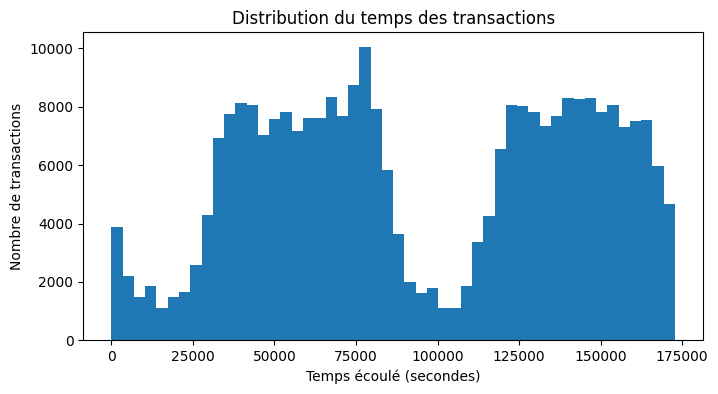

In [27]:
df["Time"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)

plt.xlabel("Temps écoulé (secondes)")
plt.ylabel("Nombre de transactions")
plt.title("Distribution du temps des transactions")
plt.show()

Pourquoi ?
Maintenant que nous avons analysé les statistiques, l’histogramme va nous permettre de voir visuellement la répartition des transactions au cours du temps.

**Interprétation :**

L'histogramme montre que les transactions ne sont pas réparties de manière uniforme dans le temps. On observe plusieurs **périodes de forte activité** séparées par des **périodes de faible activité**.

La distribution présente également un motif qui se répète, ce qui est cohérent avec les **deux jours de transactions présents dans le dataset**.

Cette analyse montre donc que l'activité des transactions **varie au cours du temps**. Nous pourrons ensuite vérifier si les transactions frauduleuses présentent une répartition temporelle différente des transactions normales.


### Explication du code

```python
df["Time"]
```

Sélectionne la colonne `Time` du DataFrame.

```python
.plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)
```

* `.plot()` : permet de créer un graphique à partir des données.
* `kind="hist"` : indique que nous voulons créer un **histogramme**.
* `bins=50` : divise les valeurs de `Time` en **50 intervalles**.
* `figsize=(8, 4)` : définit la taille du graphique.

```python
plt.xlabel("Temps écoulé (secondes)")
```

Ajoute le nom de l'axe horizontal, qui représente le temps écoulé en secondes.

```python
plt.ylabel("Nombre de transactions")
```

Ajoute le nom de l'axe vertical, qui représente le nombre de transactions.

```python
plt.title("Distribution du temps des transactions")
```

Ajoute le titre du graphique.

```python
plt.show()
```

Affiche le graphique dans le notebook.


### 17. Analyse de `Amount` selon la classe

**Pourquoi ?**

Jusqu'à présent, nous avons analysé la variable `Amount` pour l'ensemble des transactions. Il est maintenant intéressant de comparer les montants des transactions normales et frauduleuses.

**Comment ?**

Nous allons regrouper les transactions selon la variable `Class`, puis calculer les statistiques descriptives de `Amount` pour chaque classe.

**Objectif :**

Comparer les montants des transactions normales et frauduleuses afin d'identifier d'éventuelles différences dans leur distribution.


In [28]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


**Interprétation :**

Les statistiques montrent quelques différences entre les transactions normales et frauduleuses.

Pour les transactions normales (`Class = 0`), le montant moyen est de **88,29**, avec une médiane de **22,00**. Le montant maximum atteint **25 691,16**.

Pour les transactions frauduleuses (`Class = 1`), le montant moyen est de **122,21**, avec une médiane de **9,25**. Le montant maximum atteint **2 125,87**.

La moyenne des transactions frauduleuses est donc plus élevée que celle des transactions normales. Cependant, la médiane est plus faible pour les fraudes (**9,25 contre 22,00**), ce qui montre que les montants frauduleux sont eux aussi fortement dispersés.

Ces résultats montrent qu'il existe des différences dans les montants selon la classe, mais qu'il est nécessaire d'utiliser une **visualisation** pour mieux comparer les deux distributions.


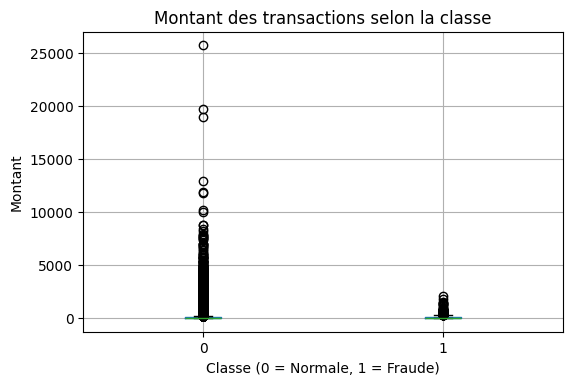

In [29]:
df.boxplot(column="Amount", by="Class", figsize=(6, 4))

plt.xlabel("Classe (0 = Normale, 1 = Fraude)")
plt.ylabel("Montant")
plt.title("Montant des transactions selon la classe")
plt.suptitle("")
plt.show()

**Interprétation :**

Le boxplot montre que les montants des transactions sont **fortement dispersés dans les deux classes**.

Pour les transactions normales (`Class = 0`), les valeurs atypiques peuvent atteindre **25 691,16**, alors que le maximum observé pour les transactions frauduleuses (`Class = 1`) est de **2 125,87**.

Dans les deux classes, la majorité des montants reste concentrée sur des valeurs relativement faibles. Cependant, les transactions normales présentent une dispersion vers les montants élevés beaucoup plus importante.

La différence d'échelle rend difficile la comparaison visuelle précise des médianes et des quartiles. Les statistiques calculées précédemment restent donc importantes pour compléter cette analyse.

Ces résultats montrent que la variable `Amount` présente des distributions différentes selon la classe. Cette relation pourra être étudiée plus précisément dans les étapes suivantes.


### Explication du code

```python id="6v9r3a"
df.boxplot(
    column="Amount",
    by="Class",
    figsize=(6, 4)
)
```

* `df.boxplot()` : crée un **boxplot** à partir du DataFrame.
* `column="Amount"` : indique que nous voulons analyser la variable `Amount`.
* `by="Class"` : crée un boxplot séparé pour chaque valeur de `Class`, donc un pour les transactions normales et un pour les transactions frauduleuses.
* `figsize=(6, 4)` : définit la taille du graphique.

```python id="q7y5fk"
plt.xlabel("Classe (0 = Normale, 1 = Fraude)")
```

Définit le nom de l'axe horizontal et précise la signification des deux classes.

```python id="f4c1zn"
plt.ylabel("Montant")
```

Définit le nom de l'axe vertical, qui représente le montant des transactions.

```python id="r8k2mv"
plt.title("Montant des transactions selon la classe")
```

Ajoute le titre du graphique.

```python id="w3n6ps"
plt.suptitle("")
```

Supprime le titre automatique ajouté par `pandas` au-dessus du graphique.

```python id="e5d9tx"
plt.show()
```

Affiche le graphique dans le notebook.
